In [1]:
# Import the libraries

%pip install yfinance 
%pip install plotly
%pip install scikit-learn
%pip install xgboost
%pip install matplotlib
%pip install seaborn

import yfinance as yf

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go 
import plotly.express as px 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC






#import plotly.io as pio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 19.0 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 37.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [yfinance]/13 [curl_cffi]t-py]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 18.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 5.2 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 38.6 

### Download the data from yfinanace

In [2]:
# Download the stock data from yfinance
import yfinance as yf
# Define the stock ticker and the date range
tickers = ['AAPL']
#tickers.append('GC=F')  # Gold futures
#tickers.append('BTC-USD')  # Bitcoin in USD
start_date = '2020-01-01'
end_date = '2026-01-01'

# Download the stock data
stocks = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
gold = yf.download('GC=F', start=start_date, end=end_date, auto_adjust=True)
BTC = yf.download('BTC-USD', start=start_date, end=end_date, auto_adjust=True)
sp500 = yf.download('^GSPC', start=start_date, end=end_date, auto_adjust=True)
nasdaq = yf.download('^IXIC', start=start_date, end=end_date, auto_adjust=True)
dowjones = yf.download('^DJI', start=start_date, end=end_date, auto_adjust=True)   

# Arrange the data so that 'Close' price can directly be used for plotting and calculations
stocks.columns = stocks.columns.droplevel(1)  # Drop the ticker level from columns
gold.columns = gold.columns.droplevel(1)
BTC.columns = BTC.columns.droplevel(1)
sp500.columns = sp500.columns.droplevel(1)
nasdaq.columns = nasdaq.columns.droplevel(1)
dowjones.columns = dowjones.columns.droplevel(1)

# Add the major indices as features to the stocks DataFrame
stocks['sp500'] = sp500['Close']
stocks['nasdaq'] = nasdaq['Close']
stocks['dowjones'] = dowjones['Close']

# reset the index to make 'Date' a column
#stocks.reset_index(inplace=True)
# Drop the Open, High, Low columns
stocks.drop(columns=['Open', 'High', 'Low'], inplace=True)

stocks.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume,sp500,nasdaq,dowjones
Date,,,,,
2020-01-02,72.400513,135480400,3257.850098,9092.190430,28868.800781
2020-01-03,71.696632,146322800,3234.850098,9020.769531,28634.880859
2020-01-06,72.267914,118387200,3246.280029,9071.469727,28703.380859
2020-01-07,71.928062,108872000,3237.179932,9068.580078,28583.679688
2020-01-08,73.085091,132079200,3253.050049,9129.240234,28745.089844


# Data Cleaning

In [3]:
# Check for missing values
stocks.isnull().sum()

# There are no missing values in the dataset, so we can proceed with the analysis.

# Check for duplicates
stocks.duplicated().sum()

# There are no duplicate rows in the dataset, so we can proceed with the analysis.



np.int64(0)

## Identify outliers

In [4]:

# Identify the outliers in the 'Close' price using the Z-score method
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(stocks['Close']))
stocks_outliers = stocks[z > 3]
print(stocks_outliers)


Q1 = stocks['Close'].quantile(0.25)
Q3 = stocks['Close'].quantile(0.75)
IQR = Q3 - Q1

outliers = stocks[(stocks['Close'] < Q1 - 1.5*IQR) | (stocks['Close'] > Q3 + 1.5*IQR)]
print(outliers)





Empty DataFrame
Columns: [Close, Volume, sp500, nasdaq, dowjones]
Index: []
Empty DataFrame
Columns: [Close, Volume, sp500, nasdaq, dowjones]
Index: []


In [5]:
# Normalize the gold and bitcoin prices to the first value to compare relative changes
def normalize_to_first(df):
    return df / df.iloc[0]

stocks['Gold'] = normalize_to_first(gold['Close'])
stocks['Bitcoin'] = normalize_to_first(BTC['Close'])


# Add the target variable, the direction of the stock price movement the next day
stocks['Target'] = np.where(stocks['Close'].shift(-1) > stocks['Close'], 1, 0)

# Add a target variable which predicts that at the end of next 5 days the stock price will be higher than today
#stocks['Target'] = np.where(stocks['Close'].shift(-5) > stocks['Close'], 1, 0)

stocks.head(20)

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target
Date,,,,,,,,
2020-01-02,72.400513,135480400,3257.850098,9092.190430,28868.800781,1.000000,0.970181,0
2020-01-03,71.696632,146322800,3234.850098,9020.769531,28634.880859,1.016202,1.020098,1
2020-01-06,72.267914,118387200,3246.280029,9071.469727,28703.380859,1.027353,1.079032,0
2020-01-07,71.928062,108872000,3237.179932,9068.580078,28583.679688,1.031027,1.133819,1
2020-01-08,73.085091,132079200,3253.050049,9129.240234,28745.089844,1.021581,1.122176,1
2020-01-09,74.637520,170108400,3274.699951,9203.429688,28956.900391,1.017842,1.094289,1
2020-01-10,74.806221,140644800,3265.350098,9178.860352,28823.769531,1.021646,1.134216,1
2020-01-13,76.404427,121532000,3288.129883,9273.929688,28907.050781,1.015677,1.131111,0
2020-01-14,75.372719,161954400,3283.149902,9251.330078,28939.669922,1.011742,1.226049,0


### Exploratory Data Analysis

<Axes: xlabel='Price', ylabel='Price'>

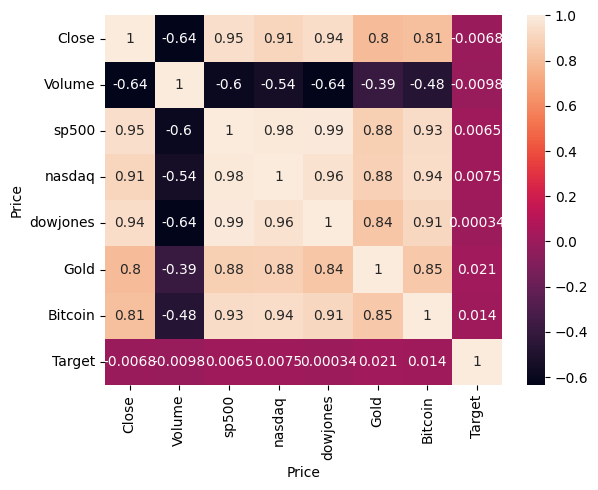

In [6]:
# Check the heatmap of the correlation between the features
import seaborn as sns
sns.heatmap(stocks.corr(), annot=True)

<Axes: xlabel='Volume', ylabel='Close'>

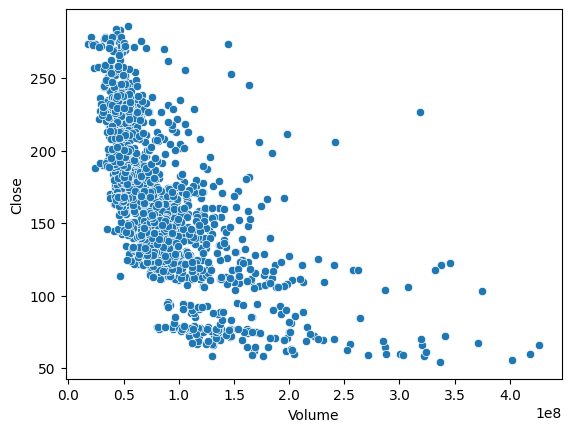

In [7]:
sns.scatterplot(x=stocks['Volume'], y=stocks['Close'])

### Feature Engineering

In [8]:
print(stocks.index)
def perform_feature_engineering(stocks):
    # Add a feature for return %
    stocks['Return'] = stocks['Close'].pct_change()*100


    # Add momentum and rate of change features
    stocks['Momentum_3'] = stocks['Close'] - stocks['Close'].shift(3)
    stocks['Momentum_5'] = stocks['Close'] - stocks['Close'].shift(5)
    stocks['ROC_5'] = stocks['Close'].pct_change(5)*100

    # Add return lags
    def add_return_lags(df, lag_days=5):
        for lag in range(1, lag_days + 1):
            df[f'Return_Lag{lag}'] = df['Return'].shift(lag)
        return df
    stocks = add_return_lags(stocks, lag_days=4)

    # Get 5 day 20 day, 50 day, and 200 day moving averages for price
    stocks['MA5'] = stocks['Close'].rolling(window=5).mean()
    stocks['MA50'] = stocks['Close'].rolling(window=50).mean()
    stocks['MA200'] = stocks['Close'].rolling(window=200).mean()

    # Add a price vs moving average feature
    stocks['Price_vs_MA20'] = stocks['Close']/stocks['MA5']

    # Get the lag features for the closing price
    def add_price_lags(df, lag_days=2):
        for lag in range(1, lag_days + 1):
            df[f'Lag{lag}'] = df['Close'].shift(lag)
        return df
    stocks = add_price_lags(stocks, lag_days=6)

    # Moving average of volume for last 5 days
    stocks['Volume_MA5'] = stocks['Volume'].rolling(window=5).mean()

    # Moving average of volume volatility for last 5 days
    stocks['Volatility'] = stocks['Close'].rolling(window=5).std()

    # Capture volume spikes
    stocks['VolumeSpike'] = np.where(stocks['Volume'] > 
                                    (stocks['Volume'].rolling(window=20).mean() + 
                                    2*stocks['Volume'].rolling(window=20).std()), 1, 0)

    print(stocks.index)

    # Relative Strength Index (RSI)
    def RSI(df, period=14):
        delta = df['Close'].diff()
        gains = delta.where(delta > 0, 0)
        losses = -delta.where(delta < 0, 0)
        avg_gains = gains.rolling(window=period).mean()
        avg_losses = losses.rolling(window=period).mean()
        rs = avg_gains/avg_losses
        #print(rs)
        df['RSI'] = 100 - (100/(1 + rs))
        return df

    RSI(stocks, 14)

    # MACD - Moving Average Convergence Divergence
    def MACD(df, short_window=12, long_window=26, signal_window=9):
        df['EMA12'] = df['Close'].ewm(span=short_window).mean()
        df['EMA26'] = df['Close'].ewm(span=long_window).mean()
        df['MACD'] = df['EMA12'] - df['EMA26']
        df['SignalLine'] = df['MACD'].ewm(span=signal_window).mean()
        df['MACD_Histogram'] = df['MACD'] - df['SignalLine']
        return df

    MACD(stocks)

    ### Add Bollinger Bands to the stock data
# Calculate the 20-day moving average and standard deviation

    def Bollinger_Bands(df, window=20, num_std_dev=2):
        df['MA20'] = df['Close'].rolling(window=window).mean()
        df['STD20'] = df['Close'].rolling(window=window).std()
        df['UpperBand'] = df['MA20'] + (df['STD20'] * num_std_dev)
        df['LowerBand'] = df['MA20'] - (df['STD20'] * num_std_dev)
        return df
    stocks = Bollinger_Bands(stocks)  
        ###stocks.dropna(inplace=True)

    # Add the seasonality features
    stocks['DayOfWeek'] = stocks.index.dayofweek
    stocks['Month'] = stocks.index.month
    stocks['Quarter'] = stocks.index.quarter

stocks.head()

perform_feature_engineering(stocks)


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)
DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)


In [9]:
# Plot the stock price and Bollinger Bands
#pio.renderers.default = "browser"
def plot_bollinger_bands(stocks):
    fig = go.Figure().update_layout(width=1000, height=600, title='AAPL Stock Price with Bollinger Bands', xaxis_title='Date', yaxis_title='Price (USD)')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks['Close'], mode='lines', name='Close Price'))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['UpperBand'], 
                            mode = 'lines', 
                            name='Upper Bollinger Band', 
                            line=dict(color='red', dash='dot')))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['LowerBand'], 
                            mode = 'lines', 
                            name='Lower Bollinger Band', 
                            line=dict(color='red', dash='dot')))
    fig.show()
plot_bollinger_bands(stocks)

In [10]:
stocks[['Close', 'Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag4', 'Target']].head(20)

Price,Close,Return,Return_Lag1,Return_Lag2,Return_Lag3,Return_Lag4,Target
Date,,,,,,,
2020-01-02,72.400513,NaN,NaN,NaN,NaN,NaN,0
2020-01-03,71.696632,-0.972203,NaN,NaN,NaN,NaN,1
2020-01-06,72.267914,0.796804,-0.972203,NaN,NaN,NaN,0
2020-01-07,71.928062,-0.470266,0.796804,-0.972203,NaN,NaN,1
2020-01-08,73.085091,1.608591,-0.470266,0.796804,-0.972203,NaN,1
2020-01-09,74.637520,2.124139,1.608591,-0.470266,0.796804,-0.972203,1
2020-01-10,74.806221,0.226027,2.124139,1.608591,-0.470266,0.796804,1
2020-01-13,76.404427,2.136461,0.226027,2.124139,1.608591,-0.470266,0
2020-01-14,75.372719,-1.350325,2.136461,0.226027,2.124139,1.608591,0


In [11]:
# More useful plot to understand the data
stocks.dropna()
stocks['RSI_bin'] = pd.cut(stocks['RSI'], bins=5, labels=False)
#stocks.groupby('RSI_bin')['Target'].mean()
stocks.head()

# Plot the Stock Return distribution
fig = px.histogram(stocks, x='Return', nbins=50, title='Distribution of AAPL Stock Returns', labels={'Return': 'Daily Return (%)'})
fig.update_layout(width=1000, height=600)  
fig.show()

# Target variable distribution
fig = px.histogram(stocks, x='Target', title='Distribution of Target Variable (Stock Price Direction)', labels={'Target': 'Stock Direction (0=Down, 1=Up)'})
fig.update_layout(width=1000, height=600)
fig.show()
stocks['Target'].value_counts(normalize=True)*100




Target
1    53.116711
0    46.883289
Name: proportion, dtype: float64

Correlation of features with Target variable:
Price
Target            1.000000
Quarter           0.033617
Month             0.030984
Gold              0.020668
MA200             0.019822
Bitcoin           0.014293
nasdaq            0.007471
Return_Lag1       0.006997
sp500             0.006534
Return_Lag2       0.000734
Momentum_3        0.000638
dowjones          0.000336
Volatility       -0.000480
STD20            -0.000846
RSI              -0.001718
Lag6             -0.001738
LowerBand        -0.001821
MA20             -0.001843
UpperBand        -0.001849
RSI_bin          -0.003016
Lag5             -0.003130
EMA26            -0.003875
VolumeSpike      -0.005110
DayOfWeek        -0.005256
EMA12            -0.005326
Lag4             -0.006412
Close            -0.006787
Lag2             -0.007084
MA5              -0.007113
Lag3             -0.008367
Lag1             -0.008473
Volume           -0.009803
MA50             -0.009807
Return_Lag3      -0.011395
MACD_Histogram   -0.014378
Pri

<Axes: title={'center': 'Correlation of Lag Features with Target Variable'}, ylabel='Price'>

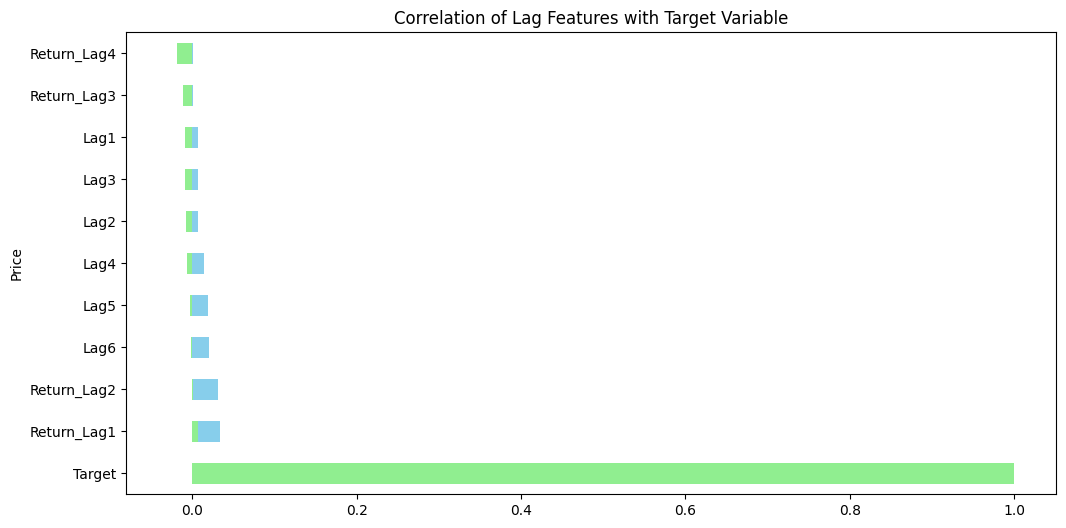

In [12]:
# Check feature correations with the target variable
corr_with_target = stocks.corr()['Target'].sort_values(ascending=False)
print("Correlation of features with Target variable:")
print(corr_with_target)
stocks.corr()
corr_with_target.plot(kind='barh', title='Correlation of Features with Target Variable', figsize=(12, 10), color='skyblue')
print(corr_with_target)
#fig = px.imshow(stocks.corr(), title='Correlation Heatmap of Stock Features', width=1000, height=800)
fig.show()

#corr_with_close = stocks.corr()['Close'].sort_values(ascending=False).drop('Close')
#print("Correlation of features with Close price:")
#print(corr_with_close)
#corr_with_close.plot(kind='barh', title='Correlation of Features with Close Price', figsize=(12, 6), color='salmon')
#fig.show()

# Correlation of lag features with the target variable
lag_features = [col for col in stocks.columns if 'Lag' in col]
corr_with_lags = stocks[lag_features + ['Target']].corr()['Target'].sort_values(ascending=False)
corr_with_lags.plot(kind='barh', title='Correlation of Lag Features with Target Variable', figsize=(12, 6), color='lightgreen')

0.5753580311872392
[0.56192286 0.59980677 0.59980677 ... 0.44884436 0.42300294 0.46138515]
Price       rmean20  Target   prob_up  buy_sell  Target_diff
Date                                                        
2024-11-18     0.45       1  0.448844         0            1
2024-11-19     0.50       1  0.456472         0            1
2024-11-20     0.50       0  0.456472         0            0
2024-11-21     0.50       1  0.515618         0            1
2024-11-22     0.50       1  0.495284         0            1
2024-11-25     0.50       1  0.456472         0            1
2024-11-26     0.50       0  0.456472         0            0
2024-11-27     0.55       1  0.561923         0            1
2024-11-29     0.60       1  0.587608         0            1
2024-12-02     0.65       1  0.595048         0            1
2024-12-03     0.65       1  0.595048         0            1
2024-12-04     0.70       1  0.639074         1            0
2024-12-05     0.65       0  0.595048         0        

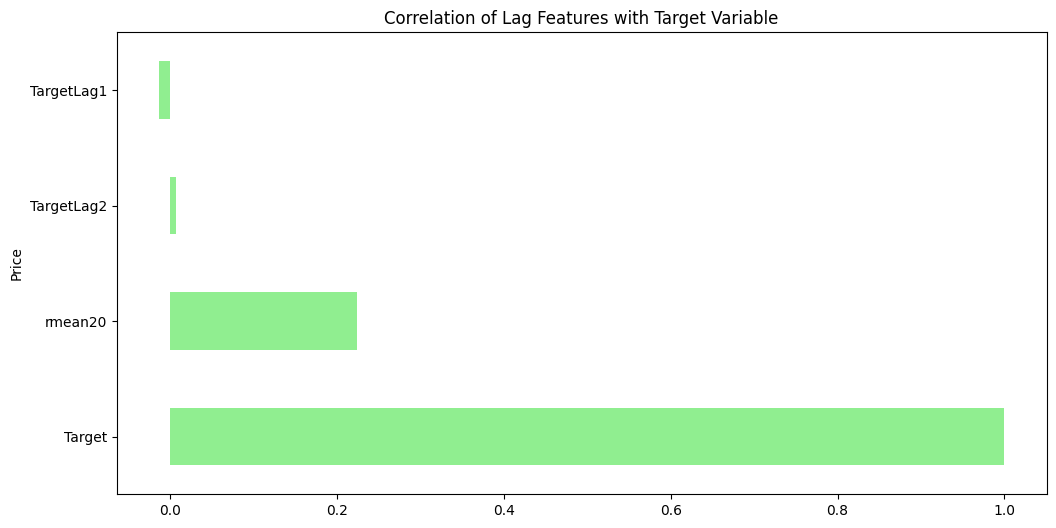

In [13]:
stocks['TargetLag1'] = stocks['Target'].shift(1)
stocks['TargetLag2'] = stocks['Target'].shift(2)
stocks['rmean3'] = stocks['Target'].rolling(window=3).mean()
stocks['rmean5'] = stocks['Target'].rolling(window=5).mean()
stocks['rmean20'] = stocks['Target'].rolling(window=20).mean()

#lags = stocks.loc[(stocks.index > '2024-11-15') & (stocks.index < '2024-12-31')][['TargetLag1', 'TargetLag2', 'Target']]
lags = stocks[['TargetLag1', 'TargetLag2', 'rmean20', 'Target']].dropna()

print(stocks['rmean3'].corr(stocks['Target']))

corr_with_lags = lags.corr()['Target'].sort_values(ascending=False)
corr_with_lags.plot(kind='barh', title='Correlation of Lag Features with Target Variable', figsize=(12, 6), color='lightgreen')
#print(lags.head(25))

#print(stocks['Target'].groupby(stocks['TargetLag1']).mean())
stocks.groupby("TargetLag1")["Target"].mean()

# Logistic Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = lags.drop(columns=['Target'])
lr = LogisticRegression(max_iter=1000).fit(X, y=lags['Target'])
probs = lr.predict_proba(X)[:, 1]  # Probability of the positive class (stock going up)
print(probs)
lags['prob_up'] = probs

lags['buy_sell'] = np.where(lags['prob_up'] > 0.6, 1, 0)
lags['Target_diff'] = lags['Target'] - lags['buy_sell']
print(lags.loc[(lags.index > '2024-11-15') & (lags.index < '2024-12-31')].drop(columns=['TargetLag1', 'TargetLag2']).head(20))
print(lags['Target_diff'].value_counts())




In [14]:


# Scatter plot of momentum indicators vs stock target
#fig = px.scatter(stocks, x='RSI', y='Target', title='Momentum Indicator vs Stock Target', width=1000, height=600)
#fig.show()

#import seaborn as sns
#sns.boxplot(x=stocks['Target'], y=stocks['RSI'])


(stocks['RSI'] > 70).groupby(stocks['Target']).mean()
#(stocks['RSI'] < 30).groupby(stocks['Target']).mean()

Target
0    0.207921
1    0.183521
Name: RSI, dtype: float64

In [15]:
# Drop rows with NaN values resulting from rolling calculations
stocks.dropna(inplace=True)

def drop_columns_and_reset_index(df, columns_to_drop):
    df.drop(columns=columns_to_drop, inplace=True)
    df.reset_index(inplace=True)
    return df
# Remove the date column as it won't be used for modeling
#stocks.reset_index(inplace=True)
# Remove the features that won't be used for modeling
#stocks = drop_columns_and_reset_index(stocks, ['Date', 'EMA12', 'EMA26', 'STD20', 'SignalLine'])
#stocks.drop(columns=['price'], inplace=True)

stocks.head()

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,Return,Momentum_3,...,LowerBand,DayOfWeek,Month,Quarter,RSI_bin,TargetLag1,TargetLag2,rmean3,rmean5,rmean20
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-15,117.193405,112559200,3483.340088,11713.870117,28494.199219,1.248409,1.596538,0,-0.396061,-3.582489,...,102.176106,3,10,4,3.0,0.0,1.0,0.333333,0.4,0.60
2020-10-16,115.552620,115393800,3483.810059,11671.559570,28606.310547,1.246835,1.572479,0,-1.400066,-2.019386,...,103.342561,4,10,4,2.0,0.0,0.0,0.000000,0.2,0.55
2020-10-19,112.601181,120639300,3426.919922,11478.879883,28195.419922,1.250508,1.630799,1,-2.554195,-5.058228,...,103.971193,0,10,4,2.0,0.0,0.0,0.333333,0.4,0.55
2020-10-20,114.086632,124423700,3443.120117,11516.490234,28308.789062,1.253132,1.655006,0,1.319214,-3.106773,...,104.404581,1,10,4,2.0,1.0,0.0,0.333333,0.2,0.55
2020-10-21,113.465286,89946000,3435.560059,11484.690430,28210.820312,1.262447,1.781025,0,-0.544626,-2.087334,...,105.941048,2,10,4,2.0,0.0,1.0,0.333333,0.2,0.50


# Modeling - using Logistical Regression

In [16]:
# Test train split
#print(stocks.head())
def test_train_split_local(df, target_col='Target', test_size=0.2):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    return X_train, X_test, y_train, y_test


def run_logistic_regression(stocks):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)
    lr.fit(X_train, y_train)

    accuracy = lr.score(X_test, y_test)
    f1 = f1_score(y_test, lr.predict(X_test))

    print(f"Logistic Regression Accuracy: {accuracy:.2f}")
    print(f"Logistic Regression F1 Score: {f1:.2f}")
    return accuracy, f1

accuracy, f1 = run_logistic_regression(stocks.copy())
results = pd.DataFrame({'Model': ['Logistic Regression'], 'Accuracy': [accuracy], 'F1 Score': [f1]})
print(results)  


Logistic Regression Accuracy: 0.53
Logistic Regression F1 Score: 0.69
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.534351  0.690355


## Using other classification models like RandomForest, KNN

In [17]:
def run_random_forest(stocks):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    rf.fit(X_train, y_train)    

    accuracy = rf.score(X_test, y_test)
    f1 = f1_score(y_test, rf.predict(X_test))
    print(f"Random Forest Accuracy: {accuracy:.2f}")
    print(f"Random Forest F1 Score: {f1:.2f}")
    return accuracy, f1

accuracy, f1 = run_random_forest(stocks.copy())
results.loc[len(results)] = ['Random Forest', accuracy, f1]
print(results)


Random Forest Accuracy: 0.93
Random Forest F1 Score: 0.93
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.534351  0.690355
1        Random Forest  0.927481  0.933333


In [18]:
# KNN
def run_knn(stocks):
    knn = KNeighborsClassifier(n_neighbors=5)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    knn.fit(X_train, y_train)

    accuracy = knn.score(X_test, y_test)
    f1 = f1_score(y_test, knn.predict(X_test))
    print(f"KNN Accuracy: {score:.2f}")
    print(f'KNN F1 Score: {f1:.2f}')
    return accuracy, f1

accuracy, f1 = run_knn(stocks.copy())
results.loc[len(results)] = ['KNN', accuracy, f1]
print(results)


NameError: name 'score' is not defined

In [ ]:
# Using SVC
def run_svm(stocks):
    svm = SVC(kernel='rbf', random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    svm.fit(X_train, y_train)

    accuracy = svm.score(X_test, y_test)
    f1 = f1_score(y_test, svm.predict(X_test))
    print(f"SVM Accuracy: {accuracy:.2f}")
    print(f'SVM F1 Score: {f1:.2f}')
    return accuracy, f1
accuracy, f1 = run_svm(stocks.copy())
results.loc[len(results)] = ['SVM', accuracy, f1]
print(results)  

SVM Accuracy: 0.53
SVM F1 Score: 0.69
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.526718  0.690000
1        Random Forest  0.927481  0.933333
2                  KNN  0.480916  0.534247
3                  SVM  0.526718  0.690000


In [ ]:
# Using XG boost
def run_xgboost(stocks):
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb.fit(X_train, y_train)   
    accuracy = xgb.score(X_test, y_test)
    f1 = f1_score(y_test, xgb.predict(X_test))
    print(f"XGBoost Accuracy: {accuracy:.2f}")
    print(f"XGBoost F1 Score: {f1:.2f}")
    return accuracy, f1

accuracy, f1 = run_xgboost(stocks.copy())
results.loc[len(results)] = ['XGBoost', accuracy, f1]
print(results)

XGBoost Accuracy: 1.00
XGBoost F1 Score: 1.00
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.526718  0.690000
1        Random Forest  0.927481  0.933333
2                  KNN  0.480916  0.534247
3                  SVM  0.526718  0.690000
4              XGBoost  1.000000  1.000000


/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:16:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Plot the accuracy and f1 scores of the models
fig = px.bar(results, x='Model', y=['Accuracy', 'F1 Score'], title='Model Performance Comparison', barmode='group', width=1000, height=600)
fig.show()

### Choose the Model hyperparameters using GridSearchCV

In [ ]:


param_grid = {
    'C': [0.01, 0.1, 1],
    'fit_intercept': [True, False]
}



### Using models with updated parameters

In [ ]:
def run_tuned_logistic_regression(stocks, grid_search):
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    lr_tuned = LogisticRegression(C=grid_search.best_params_['C'], 
        fit_intercept=grid_search.best_params_['fit_intercept'], max_iter=1000, random_state=42)
    lr_tuned.fit(X_train, y_train)
    score = lr_tuned.score(X_test, y_test)
    print(f"Tuned Logistic Regression Accuracy: {score:.2f}")

In [ ]:
stocks.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1309 entries, 2020-10-15 to 2025-12-31
Data columns (total 48 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close           1309 non-null   float64
 1   Volume          1309 non-null   int64  
 2   sp500           1309 non-null   float64
 3   nasdaq          1309 non-null   float64
 4   dowjones        1309 non-null   float64
 5   Gold            1309 non-null   float64
 6   Bitcoin         1309 non-null   float64
 7   Target          1309 non-null   int64  
 8   Return          1309 non-null   float64
 9   Momentum_3      1309 non-null   float64
 10  Momentum_5      1309 non-null   float64
 11  ROC_5           1309 non-null   float64
 12  Return_Lag1     1309 non-null   float64
 13  Return_Lag2     1309 non-null   float64
 14  Return_Lag3     1309 non-null   float64
 15  Return_Lag4     1309 non-null   float64
 16  MA5             1309 non-null   float64
 17  MA50            1309 non-n

In [ ]:
# Remove more features and see if it improves accuracy
#stocks.drop(columns=['index', 'sp500', 'VolumeSpike'], inplace=True)
stocks_cpy = stocks.copy()
stocks_cpy = drop_columns_and_reset_index(stocks_cpy, ['EMA12', 'EMA26', 'STD20', 'SignalLine', 'Return_Lag1', 'Return_Lag2'])
stocks_cpy.info()


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   Date            1309 non-null   datetime64[s]
 1   Close           1309 non-null   float64      
 2   Volume          1309 non-null   int64        
 3   sp500           1309 non-null   float64      
 4   nasdaq          1309 non-null   float64      
 5   dowjones        1309 non-null   float64      
 6   Gold            1309 non-null   float64      
 7   Bitcoin         1309 non-null   float64      
 8   Target          1309 non-null   int64        
 9   Return          1309 non-null   float64      
 10  Momentum_3      1309 non-null   float64      
 11  Momentum_5      1309 non-null   float64      
 12  ROC_5           1309 non-null   float64      
 13  Return_Lag3     1309 non-null   float64      
 14  Return_Lag4     1309 non-null   float64      
 15  MA5             1309 non-null   

### Check the importance of different features

In [ ]:

X_train, X_test, y_train, y_test = test_train_split_local(stocks.copy(), target_col='Target', test_size=0.2)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print('Random Forest Accuracy: {:.2f}'.format(rf.score(X_test, y_test)))

# print the name of the feature along with its importance
for feature, importance in zip(X_train.columns, rf.feature_importances_):
    print(f'{feature}: {importance:.4f}')

Random Forest Accuracy: 0.93
Close: 0.0115
Volume: 0.0138
sp500: 0.0125
nasdaq: 0.0129
dowjones: 0.0126
Gold: 0.0129
Bitcoin: 0.0146
Return: 0.0521
Momentum_3: 0.0319
Momentum_5: 0.0230
ROC_5: 0.0236
Return_Lag1: 0.0493
Return_Lag2: 0.0221
Return_Lag3: 0.0238
Return_Lag4: 0.0181
MA5: 0.0100
MA50: 0.0109
MA200: 0.0109
Price_vs_MA20: 0.0354
Lag1: 0.0096
Lag2: 0.0106
Lag3: 0.0097
Lag4: 0.0090
Lag5: 0.0114
Lag6: 0.0123
Volume_MA5: 0.0134
Volatility: 0.0164
VolumeSpike: 0.0011
RSI: 0.0188
EMA12: 0.0091
EMA26: 0.0089
MACD: 0.0143
SignalLine: 0.0161
MACD_Histogram: 0.0152
MA20: 0.0092
STD20: 0.0201
UpperBand: 0.0104
LowerBand: 0.0099
DayOfWeek: 0.0071
Month: 0.0083
Quarter: 0.0024
RSI_bin: 0.0039
TargetLag1: 0.0209
TargetLag2: 0.0255
rmean3: 0.1956
rmean5: 0.0839
rmean20: 0.0248


In [ ]:
def AddFEDFeatures(stocks, start_date, end_date):
    # Use the FED data to get the following features:
    # - Federal Funds Rate
    # - Inflation Rate
    # - Unemployment Rate
    %pip install fredapi
    from fredapi import Fred
    fred = Fred(api_key='c06a7676bffb4c8338823496ee6287bf')

    interest_rate = fred.get_series('FEDFUNDS', observation_start=start_date, observation_end=end_date)
    inflation_rate = fred.get_series('CPIAUCSL', observation_start=start_date, observation_end=end_date)
    unemployment_rate = fred.get_series('UNRATE', observation_start=start_date, observation_end=end_date)

    print(interest_rate.head())

    stocks['FederalFundsRate'] = interest_rate
    stocks['InflationRate'] = inflation_rate
    stocks['UnemploymentRate'] = unemployment_rate

